In [89]:
import sklearn.datasets as sk
import pandas as pd

data = sk.load_breast_cancer()
df = pd.DataFrame(data=data.data,columns=data.feature_names)
df["target"] = data.target
df = df[df.columns[df.dtypes != "object"]]
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [90]:
import numpy as np

np.random.seed(20)
numrow = df[df.target == 1].count().iloc[0]
test_df = df[df.target == 0].iloc[np.random.randint(0,100,size=3),:]
test_df = pd.concat([test_df, df[df.target == 1].iloc[np.random.randint(0,100,size=3),:]])
test_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
194,14.86,23.21,100.40,671.4,0.10440,0.19800,0.16970,0.08878,0.1737,0.06672,...,27.78,118.60,784.7,0.1316,0.4648,0.4589,0.17270,0.3000,0.08701,0
172,15.46,11.89,102.50,736.9,0.12570,0.15550,0.20320,0.10970,0.1966,0.07069,...,17.04,125.00,1102.0,0.1531,0.3583,0.5830,0.18270,0.3216,0.10100,0
15,14.54,27.54,96.73,658.8,0.11390,0.15950,0.16390,0.07364,0.2303,0.07077,...,37.13,124.10,943.2,0.1678,0.6577,0.7026,0.17120,0.4218,0.13410,0
195,12.91,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,0.1829,0.05667,...,22.00,90.81,600.6,0.1097,0.1506,0.1764,0.08235,0.3024,0.06949,1
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.09966,0.07064,0.2116,0.06346,...,18.24,109.40,803.6,0.1277,0.3089,0.2604,0.13970,0.3151,0.08473,1
187,11.71,17.19,74.68,420.3,0.09774,0.06141,0.03809,0.03239,0.1516,0.06095,...,21.39,84.42,521.5,0.1323,0.1040,0.1521,0.10990,0.2572,0.07097,1


In [91]:
from scipy.spatial.distance import pdist, squareform

vi = np.linalg.inv(df.cov())
pure_test_df = test_df.iloc[:,:-1]
# distance = pd.concat([                     pd.DataFrame(squareform(pdist(pure_test_df, metric="Euclidean")),          columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Euclidean"]    *6,index=pure_test_df.index,name="DistType")],axis=1)
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Cityblock")),          columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Manhattan"]    *6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Chebyshev")),          columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Chebyshev"]    *6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Cosine")),             columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Cosine"]       *6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance = pd.concat([distance, pd.concat([pd.DataFrame(squareform(pdist(pure_test_df, metric="Mahalanobis", VI=vi)), columns=pure_test_df.index,index=pure_test_df.index),pd.Series(["Mahalanobis"]  *6,index=pure_test_df.index,name="DistType")],axis=1)])
# distance

# manhattan = squareform(pdist(pure_test_df, metric="Cityblock"))
# chebyshev = squareform(pdist(pure_test_df, metric="Chebyshev"))
# cosine    = squareform(pdist(pure_test_df, metric="Cosine"))
# mahalanobis = squareform(pdist(pure_test_df, metric='Mahalanobis', VI=vi))
# mahalanobis

dist_mats = {
    "Euclidean": squareform(pdist(pure_test_df, metric="Euclidean")),
    "Manhattan": squareform(pdist(pure_test_df, metric="Cityblock")),
    "Chebyshev": squareform(pdist(pure_test_df, metric="Chebyshev")),
    "Cosine": squareform(pdist(pure_test_df, metric="Cosine")),
    "Mahalanobis": squareform(pdist(pure_test_df, metric="Mahalanobis", VI=vi))
}

dist_mats = {
    name: pd.DataFrame(mat, index=pure_test_df.index, columns=pure_test_df.index)
    for name, mat in dist_mats.items()
}

for name, df_mat in dist_mats.items():
    print(f"\n=== {name} Distance ===")
    display(df_mat)


=== Euclidean Distance ===


,194,172,15,195,89,187
194,0.000000,325.030431,159.648270,243.295630,36.149263,366.482289
172,325.030431,0.000000,179.300684,550.001482,310.773616,663.663793
15,159.648270,179.300684,0.000000,373.653909,142.715566,487.210821
195,243.295630,550.001482,373.653909,0.000000,246.677147,124.909279
89,36.149263,310.773616,142.715566,246.677147,0.000000,367.349434
187,366.482289,663.663793,487.210821,124.909279,367.349434,0.000000



=== Manhattan Distance ===


,194,172,15,195,89,187
194,0.000000,437.840462,204.681338,414.460353,89.095952,603.494783
172,437.840462,0.000000,294.881072,824.868671,417.303008,1014.142605
15,204.681338,294.881072,0.000000,584.324203,207.307044,773.385729
195,414.460353,824.868671,584.324203,0.000000,409.858459,195.788204
89,89.095952,417.303008,207.307044,409.858459,0.000000,599.140483
187,603.494783,1014.142605,773.385729,195.788204,599.140483,0.000000



=== Chebyshev Distance ===


,194,172,15,195,89,187
194,0.0,317.3,158.5,184.1,19.5,263.2
172,317.3,0.0,158.8,501.4,298.4,580.5
15,158.5,158.8,0.0,342.6,139.6,421.7
195,184.1,501.4,342.6,0.0,203.0,96.1
89,19.5,298.4,139.6,203.0,0.0,282.1
187,263.2,580.5,421.7,96.1,282.1,0.0



=== Cosine Distance ===


,194,172,15,195,89,187
194,0.000000,0.007478,0.004825,0.000043,0.000597,0.000607
172,0.007478,0.000000,0.000622,0.007960,0.004397,0.005266
15,0.004825,0.000622,0.000000,0.005201,0.002793,0.002834
195,0.000043,0.007960,0.005201,0.000000,0.000800,0.000623
89,0.000597,0.004397,0.002793,0.000800,0.000000,0.000646
187,0.000607,0.005266,0.002834,0.000623,0.000646,0.000000



=== Mahalanobis Distance ===


,194,172,15,195,89,187
194,0.000000,NaN,368.841511,NaN,NaN,NaN
172,NaN,0.0,NaN,NaN,NaN,NaN
15,368.841511,NaN,0.000000,NaN,NaN,NaN
195,NaN,NaN,NaN,0.0,NaN,NaN
89,NaN,NaN,NaN,NaN,0.0,NaN
187,NaN,NaN,NaN,NaN,NaN,0.0


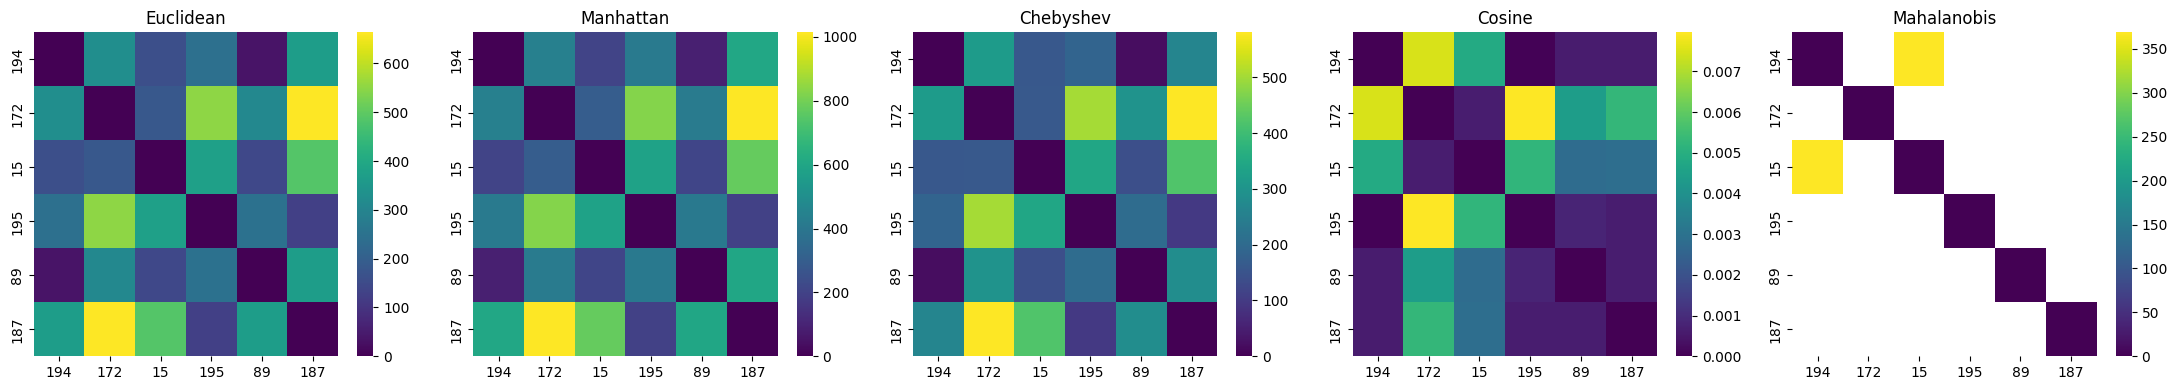

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, mat) in zip(axes, dist_mats.items()):
    sns.heatmap(mat, cmap="viridis", ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()